📗 Cell 1:

Imports essential libraries such as pandas, numpy, matplotlib, and seaborn for data analysis and visualization, along with sklearn modules for building and evaluating machine learning models.

📗 Cell 2:

Loads the Pumpkin_Seeds_Dataset.xlsx file into a pandas DataFrame for further processing.

📗 Cell 3:

Displays the first few rows of the dataset to provide an initial look at the structure and content.

📘 Cell 3A:

Generates histograms for all numerical features to visualize their distributions and identify potential skewness or irregular patterns.

📘 Cell 3B:

Calculates the skewness of each numerical feature to quantify the asymmetry of the data distribution, which helps in determining whether transformations like log-scaling are needed.

📘 Cell 3C:

Creates a count plot to display the distribution of different classes in the target variable, highlighting any potential class imbalance.

📗 Cell 4:

Separates the dataset into features (X) and target (y), followed by splitting them into training and testing subsets using train_test_split.

📗 Cell 5:

Applies label encoding to convert categorical class labels into numerical format, enabling compatibility with machine learning models.

📗 Cell 6:

Standardizes the feature values using StandardScaler to ensure all features contribute equally to the model by bringing them to a common scale.

📗 Cell 7:

Initializes and trains a Support Vector Machine (SVM) classifier with a regularization parameter C=1.0 using the scaled training data.

📗 Cell 8:

Makes predictions on the test data using the trained SVM model.

📗 Cell 9:

Evaluates model performance using accuracy, a classification report (precision, recall, F1-score), and a confusion matrix for visual representation of predictions vs. actual labels.

📙 Cell 10:

Utilizes GridSearchCV with cross-validation to explore a range of C values and identify the optimal regularization parameter for the SVM.

📙 Cell 11:

Displays the best-performing hyperparameter (C) found during grid search and the corresponding cross-validation accuracy.

📙 Cell 12:

Re-evaluates the model using the best-found parameters to verify test set performance and compare it with the initial model.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset

In [ ]:

df = pd.read_excel('Pumpkin_Seeds_Dataset.xlsx')

df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


Explore the data

In [4]:
# Basic info
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique values in each column:\n", df.nunique())

Shape: (2500, 13)

Data types:
 Area                   int64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Convex_Area            int64
Equiv_Diameter       float64
Eccentricity         float64
Solidity             float64
Extent               float64
Roundness            float64
Aspect_Ration        float64
Compactness          float64
Class                 object
dtype: object

Missing values:
 Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Convex_Area          0
Equiv_Diameter       0
Eccentricity         0
Solidity             0
Extent               0
Roundness            0
Aspect_Ration        0
Compactness          0
Class                0
dtype: int64

Unique values in each column:
 Area                 2424
Perimeter            2490
Major_Axis_Length    2499
Minor_Axis_Length    2497
Convex_Area          2445
Equiv_Diameter       2424
Eccentricity         1295
Solidity              166
Extent 

Encode Target Column

In [ ]:
label_encoder = LabelEncoder()
df['Class'] = label_encoder.fit_transform(df['Class'])


print("Class mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
df.head()

Class mapping: {'Çerçevelik': np.int64(0), 'Ürgüp Sivrisi': np.int64(1)}


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,0
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,0
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,0
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,0
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,0


Separate Features & Target

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

Plot Feature Distributions

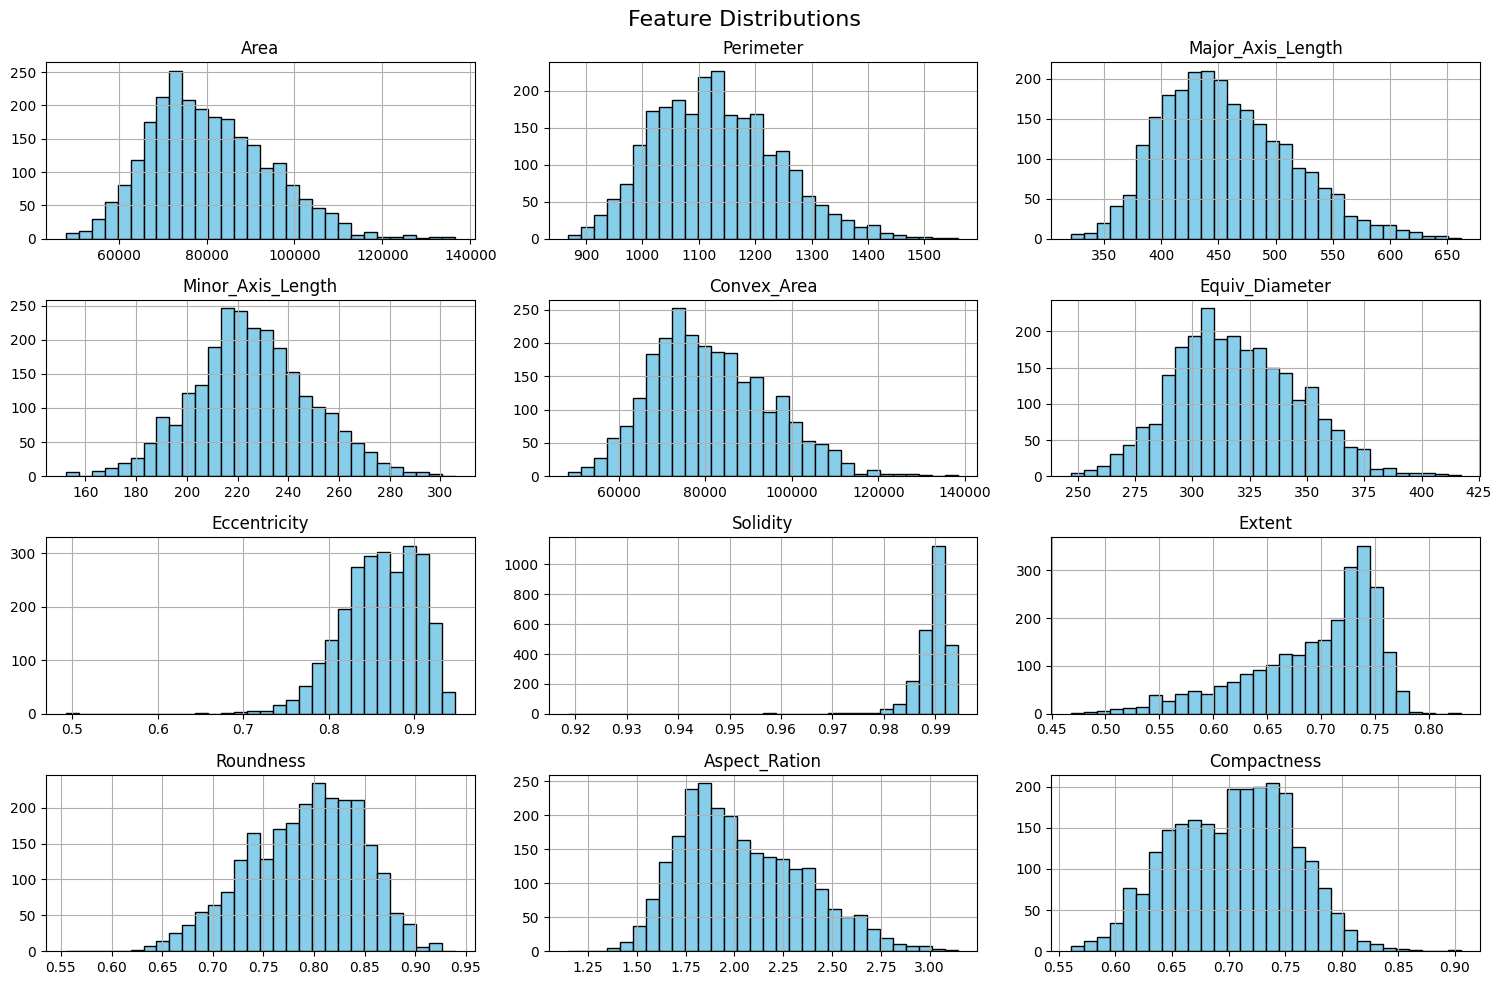

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


feature_columns = df.columns[:-1]

df[feature_columns].hist(bins=30, figsize=(15, 10), layout=(4, 3), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

Check For Skewness

In [17]:
skew_values = df[feature_columns].skew().sort_values(ascending=False)
print("Skewness of features:\n")
print(skew_values)

Skewness of features:

Aspect_Ration        0.548231
Major_Axis_Length    0.502980
Area                 0.495999
Convex_Area          0.494016
Perimeter            0.414539
Equiv_Diameter       0.271868
Minor_Axis_Length    0.104303
Compactness         -0.062377
Roundness           -0.372687
Eccentricity        -0.748623
Extent              -1.026568
Solidity            -5.691009
dtype: float64


Class Distribution Visualization

/tmp/ipykernel_10259/2790865703.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='pastel')


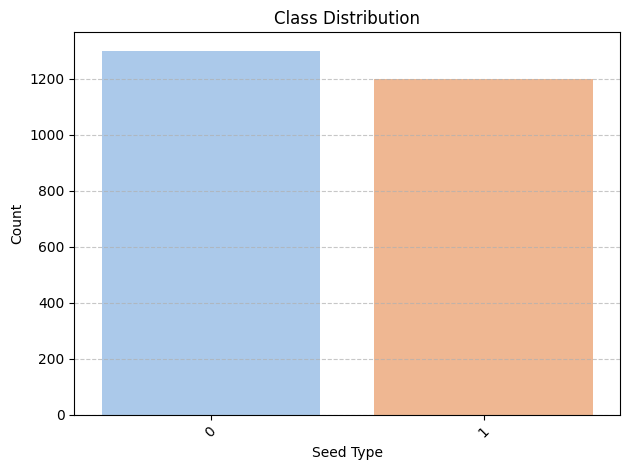

In [19]:
sns.countplot(x='Class', data=df, palette='pastel')
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.xlabel("Seed Type")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scale The Features

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train The SVM Model

In [9]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

SVC()

Evaluate The Model

Accuracy: 0.878

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.89       260
           1       0.91      0.83      0.87       240

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



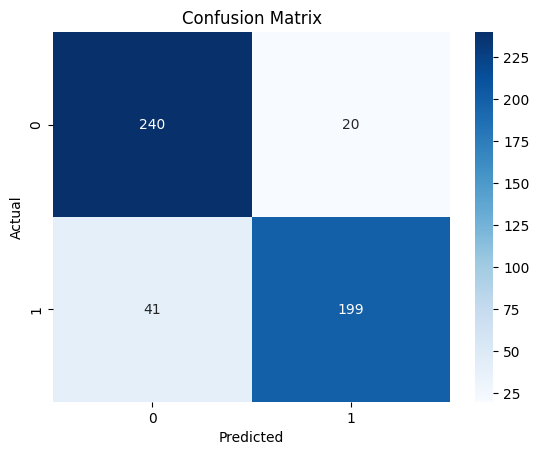

In [10]:
y_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

HyperParameter Tuning With GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale'],       # Keep gamma fixed for now
    'kernel': ['rbf']         # Keep kernel fixed as 'rbf'
}

# GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(SVC(), param_grid, cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'gamma': ['scale'],
                         'kernel': ['rbf']},
             verbose=1)

Print Best Hyperparameters And CV Accuracy

In [12]:
print("Best Parameters from GridSearchCV:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters from GridSearchCV: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8895000000000002


Evaluate Best Model On Test Set

Test Set Accuracy: 0.878

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.89       260
           1       0.91      0.83      0.87       240

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



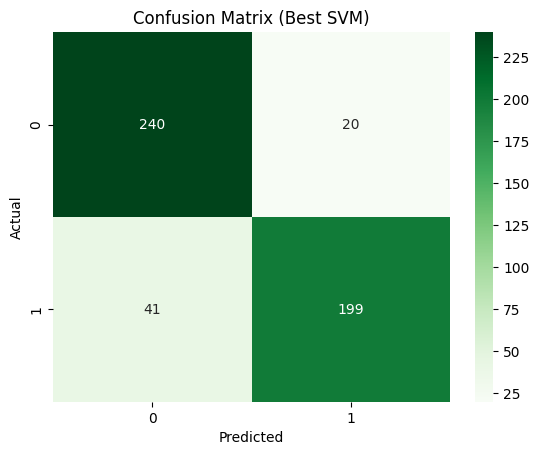

In [13]:
# Use the best estimator found by GridSearchCV
best_svm = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_svm.predict(X_test_scaled)

# Accuracy and report
print("Test Set Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best SVM)")
plt.show()